In [1]:
from google.colab import files
uploaded = files.upload()  # upload your service account JSON again

from google.cloud import bigquery
client = bigquery.Client.from_service_account_json(list(uploaded.keys())[0])
print("Connected to project:", client.project)

Saving phonic-chemist-509603-v9-6d0523a7b77d.json to phonic-chemist-509603-v9-6d0523a7b77d.json
Connected to project: phonic-chemist-509603-v9


In [2]:
#Step 1: Reshape sales data (wide → long) for time-series analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate total daily sales across ALL items/stores using SQL (fast, done in BigQuery)
day_cols = ", ".join([f"SUM(d_{i}) as d_{i}" for i in range(1, 1914)])

query = f"""
SELECT {day_cols}
FROM `{client.project}.m5_raw.sales_train_validation`
"""
daily_totals = client.query(query).to_dataframe()
print(daily_totals.shape)

(1, 1913)


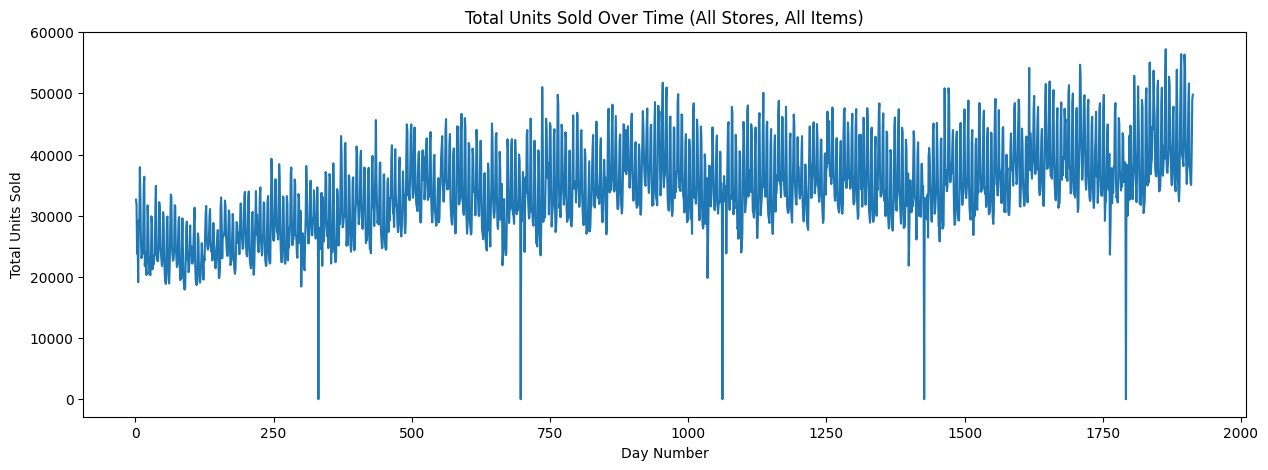

In [3]:
#Step 2: Convert to long format and plot the overall trend
daily_totals_long = daily_totals.T.reset_index()
daily_totals_long.columns = ["day", "total_units_sold"]
daily_totals_long["day_num"] = daily_totals_long["day"].str.replace("d_", "").astype(int)
daily_totals_long = daily_totals_long.sort_values("day_num")

plt.figure(figsize=(15, 5))
plt.plot(daily_totals_long["day_num"], daily_totals_long["total_units_sold"])
plt.title("Total Units Sold Over Time (All Stores, All Items)")
plt.xlabel("Day Number")
plt.ylabel("Total Units Sold")
plt.show()

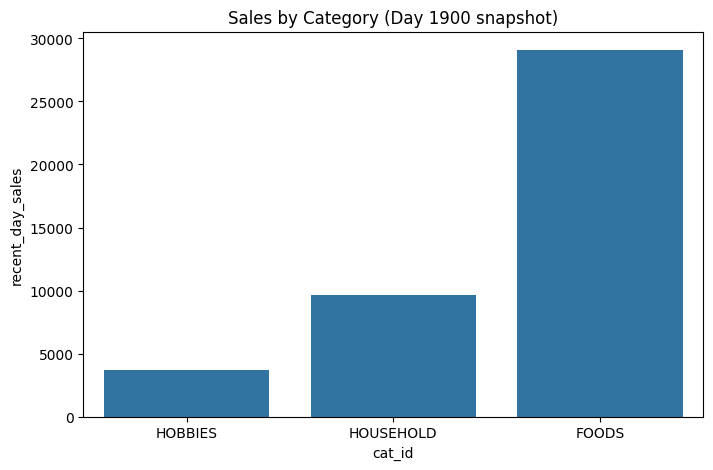

In [4]:
#Step 3: Sales by category
query_cat = f"""
SELECT cat_id, SUM(d_1900) as recent_day_sales
FROM `{client.project}.m5_raw.sales_train_validation`
GROUP BY cat_id
"""
cat_sales = client.query(query_cat).to_dataframe()

plt.figure(figsize=(8, 5))
sns.barplot(data=cat_sales, x="cat_id", y="recent_day_sales")
plt.title("Sales by Category (Day 1900 snapshot)")
plt.show()

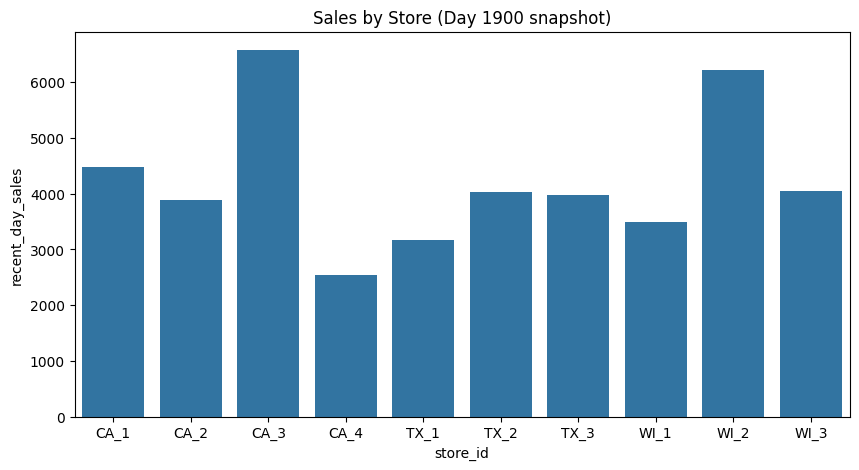

In [5]:
#Step 4: Sales by store
query_store = f"""
SELECT store_id, SUM(d_1900) as recent_day_sales
FROM `{client.project}.m5_raw.sales_train_validation`
GROUP BY store_id
ORDER BY store_id
"""
store_sales = client.query(query_store).to_dataframe()

plt.figure(figsize=(10, 5))
sns.barplot(data=store_sales, x="store_id", y="recent_day_sales")
plt.title("Sales by Store (Day 1900 snapshot)")
plt.show()

In [7]:
#Step 5: Weekly seasonality using calendar
query_weekday2 = f"""
SELECT wday, weekday, COUNT(*) as day_count
FROM `{client.project}.m5_raw.calendar`
GROUP BY wday, weekday
ORDER BY wday
"""
print(client.query(query_weekday2).to_dataframe())

   wday    weekday  day_count
0     1   Saturday        282
1     2     Sunday        282
2     3     Monday        281
3     4    Tuesday        281
4     5  Wednesday        281
5     6   Thursday        281
6     7     Friday        281
